In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import sklearn
print(sklearn.__version__)

pd.set_option("display.max_columns", None)


1.5.1


In [29]:
import sklearn
print(sklearn.__version__)

1.5.1


In [31]:
DATA_PATH = Path(r"C:\Users\Admin\Documents\timb_tobacco_dataset_2021_2026_(1).csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Update DATA_PATH to your tobacco CSV file."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")
print(df.columns.tolist())


Loaded 2,400 rows and 39 columns
['record_id', 'farm_id', 'year', 'province', 'district', 'farm_size_ha', 'tobacco_area_ha', 'irrigation', 'planting_day_of_year', 'rainfall_mm', 'avg_temperature_c', 'relative_humidity_pct', 'fertilizer_kg_per_ha', 'fertilizer_price_usd_per_50kg', 'diesel_price_usd_per_litre', 'seed_cost_usd_per_ha', 'pesticide_cost_usd_per_ha', 'labor_cost_usd_per_ha', 'curing_energy_cost_usd_per_ha', 'pesticide_applications', 'extension_visits', 'mechanization_index', 'estimated_inflation_index', 'reference_exchange_rate_zwl_per_usd', 'yield_kg_per_ha', 'production_kg', 'grade_score', 'tobacco_grade', 'auction_volume_kg', 'average_auction_price_usd_per_kg', 'gross_revenue_usd', 'estimated_input_cost_usd', 'estimated_net_income_usd', 'export_share', 'export_volume_kg', 'export_value_usd', 'revenue_per_ha_usd', 'cost_per_kg_usd', 'profit_margin_pct']


In [33]:
required_columns = {
    "year",
    "yield_kg_per_ha",
    "rainfall_mm",
    "avg_temperature_c",
    "relative_humidity_pct",
    "fertilizer_kg_per_ha",
    "planting_day_of_year",
    "pesticide_applications",
    "extension_visits",
    "mechanization_index",
    "province",
    "irrigation",
}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
print(X.columns.tolist())
df.head()


NameError: name 'X' is not defined

In [35]:
df = df.drop_duplicates().copy()
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year", "yield_kg_per_ha"]).sort_values("year")
print(f"Years covered: {int(df['year'].min())} to {int(df['year'].max())}")
print(df.groupby("year")["yield_kg_per_ha"].agg(["count", "mean", "std"]))


Years covered: 2021 to 2026
      count        mean         std
year                               
2021    400  1770.88200  249.056647
2022    400  1823.34400  257.146815
2023    400  1853.89000  260.925171
2024    400  1877.35875  273.706093
2025    400  1929.75100  268.719708
2026    400  1968.82700  267.538580


In [37]:
df.tail()

,record_id,farm_id,year,province,district,farm_size_ha,tobacco_area_ha,irrigation,planting_day_of_year,rainfall_mm,avg_temperature_c,relative_humidity_pct,fertilizer_kg_per_ha,fertilizer_price_usd_per_50kg,diesel_price_usd_per_litre,seed_cost_usd_per_ha,pesticide_cost_usd_per_ha,labor_cost_usd_per_ha,curing_energy_cost_usd_per_ha,pesticide_applications,extension_visits,mechanization_index,estimated_inflation_index,reference_exchange_rate_zwl_per_usd,yield_kg_per_ha,production_kg,grade_score,tobacco_grade,auction_volume_kg,average_auction_price_usd_per_kg,gross_revenue_usd,estimated_input_cost_usd,estimated_net_income_usd,export_share,export_volume_kg,export_value_usd,revenue_per_ha_usd,cost_per_kg_usd,profit_margin_pct
2127,2128,SIM-KAR-028,2026,Mashonaland West,Karoi,2.70,1.03,1,310,608.4,22.3,63.2,367.1,921.06,1.92,149.12,126.82,418.02,208.56,3,2,0.501,1.7,3000,2061.7,2123.5,70.9,B,1842.3,1.962,3615.42,1387.37,2228.05,0.797,1468.6,2975.25,3510.12,0.6533,61.63
2126,2127,SIM-KAR-027,2026,Mashonaland West,Karoi,10.99,5.28,0,281,631.1,25.3,54.3,408.0,1039.96,1.98,137.78,151.86,411.95,230.66,5,4,0.430,1.7,3000,2155.4,11371.0,75.1,B,10294.5,2.336,24046.55,7644.81,16401.74,0.779,8022.3,17623.98,4554.27,0.6723,68.21
2125,2126,SIM-KAR-026,2026,Mashonaland West,Karoi,5.10,3.34,0,294,594.4,25.7,60.8,455.0,942.41,1.96,140.26,142.34,396.00,203.98,4,4,0.456,1.7,3000,2011.8,6720.1,76.9,B,6304.3,2.563,16157.60,4742.69,11414.91,0.674,4251.9,10544.86,4837.60,0.7057,70.65
2135,2136,SIM-KAR-036,2026,Mashonaland West,Karoi,2.34,1.60,0,300,687.8,20.9,72.6,447.3,919.06,2.00,146.29,149.82,400.35,200.17,8,3,0.520,1.7,3000,1983.6,3182.5,69.1,C,2880.8,2.116,6096.89,2238.24,3858.64,0.509,1466.3,3164.83,3810.56,0.7033,63.29
2399,2400,SIM-BIN-050,2026,Matabeleland North,Binga,7.48,5.53,0,325,714.9,23.5,59.3,220.0,972.28,2.02,134.99,130.97,416.15,212.48,5,2,0.642,1.7,3000,1468.5,8127.5,66.6,C,7725.9,2.435,18814.41,6798.19,12016.23,0.821,6344.1,15668.65,3402.24,0.8364,63.87


In [38]:
feature_columns = [
    "rainfall_mm",
    "avg_temperature_c",
    "relative_humidity_pct",
    "fertilizer_kg_per_ha",
    "planting_day_of_year",
    "pesticide_applications",
    "extension_visits",
    "mechanization_index",
    "province",
    "irrigation",
]
target_column = "yield_kg_per_ha"

model_data = df[["year", *feature_columns, target_column]].dropna().copy()
X = model_data[feature_columns]
y = model_data[target_column]


In [41]:
categorical_features = ["province", "irrigation"]
numeric_features = [column for column in feature_columns if column not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features),
    ]
)


In [43]:
# Keep the latest year as an honest out-of-time test set.
cutoff_year = model_data["year"].max()
train_mask = model_data["year"] < cutoff_year
test_mask = model_data["year"] == cutoff_year

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

print(f"Training years: {sorted(model_data.loc[train_mask, 'year'].unique())}")
print(f"Testing year: {int(cutoff_year)}")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training years: [2021, 2022, 2023, 2024, 2025]
Testing year: 2026
Training rows: 2000
Testing rows: 400


In [45]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=400,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:,.2f} kg/ha")
print(f"RMSE: {rmse:,.2f} kg/ha")
print(f"R2: {r2:.3f}")


MAE: 141.60 kg/ha
RMSE: 176.34 kg/ha
R2: 0.564


In [46]:
predictions = pd.DataFrame({
    "actual_yield": y_test.to_numpy(),
    "predicted_yield": y_pred,
})
predictions.head()


,actual_yield,predicted_yield
0,1898.6,1874.548492
1,1840.0,1867.527403
2,1807.2,1829.084121
3,1958.6,1845.855156
4,1619.2,1582.482097


In [47]:
print(y_pred[:10])


[1874.54849187 1867.52740288 1829.08412082 1845.85515585 1582.48209732
 1980.9126624  1911.56747907 1824.45245863 1678.92254147 1873.22099206]


In [48]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


Random Forest Results
---------------------
MAE : 141.60022099993245
RMSE: 176.338913729394
R2  : 0.5644775136558131


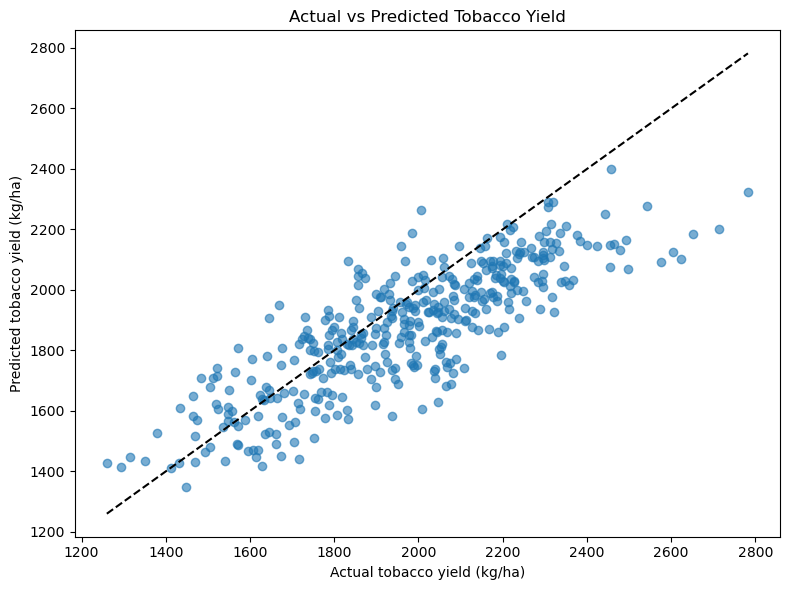

In [53]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
plt.xlabel("Actual tobacco yield (kg/ha)")
plt.ylabel("Predicted tobacco yield (kg/ha)")
plt.title("Actual vs Predicted Tobacco Yield")
plt.tight_layout()
plt.show()


In [54]:
# Refit on all available history before generating the future scenario.
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=600,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
final_model.fit(X, y)

numeric_scenario_features = [
    "rainfall_mm",
    "avg_temperature_c",
    "relative_humidity_pct",
    "fertilizer_kg_per_ha",
    "planting_day_of_year",
    "pesticide_applications",
    "extension_visits",
    "mechanization_index",
]
latest_year = int(model_data["year"].max())
historical_bounds = model_data[numeric_scenario_features].quantile([0.01, 0.99])
future_rows = []

for province, province_data in model_data.groupby("province"):
    province_data = province_data.sort_values("year")
    latest = province_data.iloc[-1]
    recent = province_data.tail(min(3, len(province_data)))
    for step in range(1, 6):
        scenario = {"year": latest_year + step, "province": province}
        for column in numeric_scenario_features:
            if len(recent) >= 2:
                change_per_year = (
                    recent[column].iloc[-1] - recent[column].iloc[0]
                ) / (len(recent) - 1)
            else:
                change_per_year = 0.0
            scenario[column] = latest[column] + change_per_year * step
            scenario[column] = np.clip(
                scenario[column],
                historical_bounds.loc[0.01, column],
                historical_bounds.loc[0.99, column],
            )
        scenario["irrigation"] = latest["irrigation"]
        future_rows.append(scenario)

future_data = pd.DataFrame(future_rows)
future_transformed = final_model.named_steps["preprocessor"].transform(
    future_data[feature_columns]
)
tree_predictions = np.column_stack(
    [tree.predict(future_transformed) for tree in final_model.named_steps["regressor"].estimators_]
)
future_data["predicted_yield_kg_per_ha"] = tree_predictions.mean(axis=1)
future_data["lower_80pct_kg_per_ha"] = np.percentile(tree_predictions, 10, axis=1)
future_data["upper_80pct_kg_per_ha"] = np.percentile(tree_predictions, 90, axis=1)
forecast = future_data[
    [
        "year",
        "province",
        "predicted_yield_kg_per_ha",
        "lower_80pct_kg_per_ha",
        "upper_80pct_kg_per_ha",
    ]
].sort_values(["year", "province"])
forecast


,year,province,predicted_yield_kg_per_ha,lower_80pct_kg_per_ha,upper_80pct_kg_per_ha
0,2027,Manicaland,1888.196716,1685.063333,2080.193333
5,2027,Mashonaland Central,1896.613362,1696.505000,2136.655000
10,2027,Mashonaland East,1903.893390,1714.555000,2115.990000
15,2027,Mashonaland West,2123.211200,1908.395000,2361.216000
20,2027,Matabeleland North,1463.022458,1327.100000,1561.885000
25,2027,Midlands,1992.850560,1741.080667,2146.880000
1,2028,Manicaland,1931.016565,1708.920000,2105.886667
6,2028,Mashonaland Central,1810.843317,1625.633333,1989.550000
11,2028,Mashonaland East,1915.620006,1702.200000,2148.250000
16,2028,Mashonaland West,2210.895487,2019.177500,2378.237857


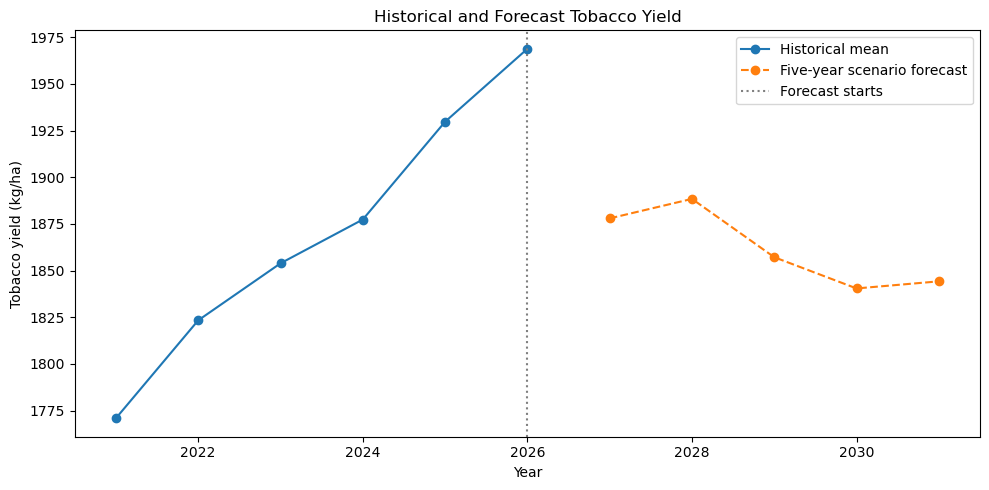

In [55]:
annual_history = (
    model_data.groupby("year", as_index=False)[target_column]
    .mean()
    .rename(columns={target_column: "yield_kg_per_ha"})
)
annual_forecast = (
    forecast.groupby("year", as_index=False)["predicted_yield_kg_per_ha"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    annual_history["year"],
    annual_history["yield_kg_per_ha"],
    marker="o",
    label="Historical mean",
)
plt.plot(
    annual_forecast["year"],
    annual_forecast["predicted_yield_kg_per_ha"],
    marker="o",
    linestyle="--",
    label="Five-year scenario forecast",
)
plt.axvline(latest_year, color="gray", linestyle=":", label="Forecast starts")
plt.xlabel("Year")
plt.ylabel("Tobacco yield (kg/ha)")
plt.title("Historical and Forecast Tobacco Yield")
plt.legend()
plt.tight_layout()
plt.show()


In [60]:
# Robustness checks: rolling-origin validation and data-quality checks.
validation_years = sorted(model_data["year"].unique())[-4:]
backtest_rows = []

for validation_year in validation_years:
    train_mask = model_data["year"] < validation_year
    test_mask = model_data["year"] == validation_year
    if train_mask.sum() == 0 or test_mask.sum() == 0:
        continue

    rolling_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "regressor",
                RandomForestRegressor(
                    n_estimators=300,
                    min_samples_leaf=2,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    )
    rolling_model.fit(X.loc[train_mask], y.loc[train_mask])
    rolling_prediction = rolling_model.predict(X.loc[test_mask])
    baseline_prediction = np.repeat(y.loc[train_mask].mean(), test_mask.sum())

    backtest_rows.append(
        {
            "validation_year": int(validation_year),
            "model_mae": mean_absolute_error(y.loc[test_mask], rolling_prediction),
            "baseline_mae": mean_absolute_error(y.loc[test_mask], baseline_prediction),
            "model_rmse": np.sqrt(mean_squared_error(y.loc[test_mask], rolling_prediction)),
        }
    )

backtest_results = pd.DataFrame(backtest_rows)
print("Rolling-origin validation")
display(backtest_results.round(2))
print(
    "Average model MAE:", round(backtest_results["model_mae"].mean(), 2),
    "| Average baseline MAE:", round(backtest_results["baseline_mae"].mean(), 2),
)

numeric_model_data = model_data.select_dtypes(include=np.number)
quality_report = pd.DataFrame(
    {
        "missing_values": numeric_model_data.isna().sum(),
        "infinite_values": np.isinf(numeric_model_data).sum(),
    }
)
print("Numeric data-quality issues")
display(quality_report[(quality_report != 0).any(axis=1)])


Rolling-origin validation


,validation_year,model_mae,baseline_mae,model_rmse
0,2023,123.00,220.87,153.25
1,2024,134.86,226.29,168.14
2,2025,145.15,231.72,181.95
3,2026,141.41,238.54,176.25


Average model MAE: 136.11 | Average baseline MAE: 229.35
Numeric data-quality issues


,missing_values,infinite_values


In [61]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [62]:
import joblib

# Suppose you already have a sklearn Pipeline: preprocessor + regressor
joblib.dump (rolling_model,"tobacco_yield_model.joblib")

['tobacco_yield_model.joblib']

In [69]:
import joblib

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# Train the model on ALL your data
final_model.fit(X, y)

# Save it with the NEW version
joblib.dump(final_model, "tobacco_yield_model.joblib")
print("✅ New model saved successfully!")

✅ New model saved successfully!
